In [1]:
!pip install swig
!pip install "gymnasium[box2d]"

In [2]:
import gymnasium as gym
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from torch.distributions import Normal
import imageio
from tqdm.auto import tqdm


In [3]:
def visualize(gif_path="car_racing.gif", actor=None):
    # Создаем отдельное окружение для записи анимации прохождения трассы.
    env = make_env(render_mode="rgb_array")
    frames = []

    obs, _ = env.reset()
    state = init_stack(obs)
    terminated = False
    truncated = False

    while not (terminated or truncated):
        if actor is None:
            action = env.action_space.sample()
        else:
            action, _ = sample_action(state, actor, deterministic=True)

        obs, _, terminated, truncated, _ = env.step(action)
        state = update_stack(state, obs)
        frames.append(env.render())

    env.close()

    # Сохраняем собранные кадры в анимированный файл.
    with imageio.get_writer(gif_path, mode="I", duration=0.05) as writer:
        for frame in frames:
            writer.append_data(frame)


# <a id='toc3_'></a>[A2C](#toc0_)

In [4]:
@dataclass
class Config:
    env_name: str = "CarRacing-v3"
    obs_h: int = 64
    obs_w: int = 64
    frame_stack: int = 4
    gamma: float = 0.99
    gae_lambda: float = 0.95
    rollout_steps: int = 128
    lr_actor: float = 1e-4
    lr_critic: float = 3e-4
    entropy_coef: float = 1e-3
    max_grad_norm: float = 0.5
    init_log_std: float = -1.0
    num_episodes: int = 300
    target_reward: float = 300.0
    gif_path: str = "car_racing.gif"
    actor_path: str = "actor.pt"
    critic_path: str = "critic.pt"


CONFIG = Config()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def make_env(render_mode=None):
    return gym.make(
        CONFIG.env_name,
        render_mode=render_mode,
        lap_complete_percent=0.95,
        domain_randomize=False,
        continuous=True,
    )


In [5]:
env = make_env(render_mode=None)
ACTION_DIM = env.action_space.shape[0]


In [6]:
def preprocess_frame(obs):
    # Переводим RGB-кадр в уменьшенное полутоновое изображение в диапазоне [0, 1].
    img = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
    img = cv2.resize(img, (CONFIG.obs_w, CONFIG.obs_h), interpolation=cv2.INTER_AREA)
    return img.astype(np.float32) / 255.0


def init_stack(obs):
    # Начальный стек состоит из одного и того же кадра, повторенного несколько раз.
    frame = preprocess_frame(obs)
    return np.stack([frame] * CONFIG.frame_stack, axis=-1)


def update_stack(stack, obs):
    # Сдвигаем стек и добавляем новый кадр в конец.
    frame = preprocess_frame(obs)[..., None]
    return np.concatenate([stack[..., 1:], frame], axis=-1)


def prep_obs(obs):
    # Приводим наблюдение к формату (N, C, H, W) на нужном устройстве.
    x = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
    if x.dim() == 3:
        x = x.permute(2, 0, 1).unsqueeze(0)
    elif x.dim() == 4:
        x = x.permute(0, 3, 1, 2)
    else:
        raise ValueError(f"Неожиданная форма наблюдения: {x.shape}")
    return x


In [7]:
def init_linear(layer, gain=np.sqrt(2), bias=0.0):
    nn.init.orthogonal_(layer.weight, gain)
    nn.init.constant_(layer.bias, bias)


class ActorNet(nn.Module):
    def __init__(self, action_dim, frame_stack, hidden_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(frame_stack, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(64 * 4 * 4, hidden_dim)
        self.mu_head = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Parameter(torch.full((action_dim,), CONFIG.init_log_std))
        self.apply(self._init_weights)
        nn.init.orthogonal_(self.mu_head.weight, gain=0.01)
        self.mu_head.bias.data.copy_(torch.tensor([0.0, 1.0, -2.0], dtype=torch.float32))

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv2d):
            nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
            nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            init_linear(module)

    def forward(self, obs):
        x = prep_obs(obs)
        x = self.conv(x)
        x = self.flatten(x)
        x = F.relu(self.hidden(x))
        mu = self.mu_head(x)
        std = self.log_std.clamp(-2.5, -0.2).exp().expand_as(mu)
        return mu, std


class ValueNet(nn.Module):
    def __init__(self, frame_stack, hidden_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(frame_stack, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(64 * 4 * 4, hidden_dim)
        self.output = nn.Linear(hidden_dim, 1)
        self.apply(self._init_weights)
        init_linear(self.output, gain=1.0)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv2d):
            nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
            nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            init_linear(module)

    def forward(self, obs):
        x = prep_obs(obs)
        x = self.conv(x)
        x = self.flatten(x)
        x = F.relu(self.hidden(x))
        return self.output(x).squeeze(-1)


def squash_raw_action(raw_action):
    # Приводим сырое действие к диапазонам, которые ожидает среда.
    steering = torch.tanh(raw_action[..., 0])
    gas = torch.sigmoid(raw_action[..., 1])
    brake = torch.sigmoid(raw_action[..., 2])
    return torch.stack([steering, gas, brake], dim=-1)


def sample_action(state_stack, actor, deterministic=False):
    # Строим распределение действий и возвращаем действие для среды и сырое действие.
    with torch.no_grad():
        mu, std = actor(state_stack)
        dist = Normal(mu, std)
        raw_action = mu if deterministic else dist.sample()
        env_action = squash_raw_action(raw_action)

    return (
        env_action.squeeze(0).cpu().numpy().astype(np.float32),
        raw_action.squeeze(0).cpu().numpy().astype(np.float32),
    )


actor = ActorNet(action_dim=ACTION_DIM, frame_stack=CONFIG.frame_stack).to(DEVICE)
critic = ValueNet(frame_stack=CONFIG.frame_stack).to(DEVICE)
opt_actor = torch.optim.AdamW(actor.parameters(), lr=CONFIG.lr_actor)
opt_critic = torch.optim.AdamW(critic.parameters(), lr=CONFIG.lr_critic)


Обучение:   0%|          | 0/300 [00:00<?, ?эпизод/s]

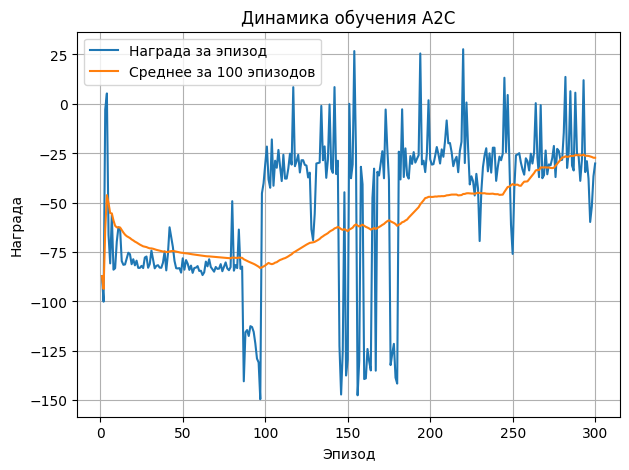

In [8]:
def compute_advantages_and_returns(rewards_t, terminated_t, values_t, last_value_t, config):
    # Вычисляем преимущества по схеме GAE и целевые значения для критика.
    advantages = torch.zeros_like(rewards_t)
    gae = torch.tensor(0.0, dtype=torch.float32, device=DEVICE)
    next_value = last_value_t

    for step_idx in reversed(range(len(rewards_t))):
        not_terminal = 1.0 - terminated_t[step_idx]
        delta = rewards_t[step_idx] + config.gamma * next_value * not_terminal - values_t[step_idx]
        gae = delta + config.gamma * config.gae_lambda * not_terminal * gae
        advantages[step_idx] = gae
        next_value = values_t[step_idx]

    returns = advantages + values_t
    return advantages, returns


def collect_rollout(env, actor, critic, state, config):
    # Собираем короткий rollout фиксированной длины и bootstrap-оценку хвоста.
    states = []
    raw_actions = []
    rewards = []
    terminated_flags = []
    rollout_reward = 0.0
    terminated = False
    truncated = False

    for _ in range(config.rollout_steps):
        states.append(state.copy())
        env_action, raw_action = sample_action(state, actor, deterministic=False)
        obs, reward, terminated, truncated, _ = env.step(env_action)
        state = update_stack(state, obs)

        raw_actions.append(raw_action)
        rewards.append(reward)
        terminated_flags.append(float(terminated))
        rollout_reward += reward

        if terminated or truncated:
            break

    with torch.no_grad():
        if terminated:
            last_value = torch.tensor(0.0, dtype=torch.float32, device=DEVICE)
        else:
            last_value = critic(state).squeeze(0)

    rollout = {
        "states": np.array(states, dtype=np.float32),
        "raw_actions": np.array(raw_actions, dtype=np.float32),
        "rewards": np.array(rewards, dtype=np.float32),
        "terminated": np.array(terminated_flags, dtype=np.float32),
        "last_value": float(last_value.item()),
        "rollout_reward": float(rollout_reward),
        "state": state,
        "finished": bool(terminated or truncated),
    }
    return rollout


def update_models(rollout, actor, critic, opt_actor, opt_critic, config):
    # Обновляем actor и critic на основе одного n-step rollout.
    states_t = torch.as_tensor(rollout["states"], dtype=torch.float32, device=DEVICE)
    raw_actions_t = torch.as_tensor(rollout["raw_actions"], dtype=torch.float32, device=DEVICE)
    rewards_t = torch.as_tensor(rollout["rewards"], dtype=torch.float32, device=DEVICE)
    terminated_t = torch.as_tensor(rollout["terminated"], dtype=torch.float32, device=DEVICE)
    last_value_t = torch.as_tensor(rollout["last_value"], dtype=torch.float32, device=DEVICE)

    mu, std = actor(states_t)
    dist = Normal(mu, std)
    log_probs = dist.log_prob(raw_actions_t).sum(-1)
    entropy = dist.entropy().sum(-1).mean()
    values_t = critic(states_t)

    advantages_t, returns_t = compute_advantages_and_returns(
        rewards_t=rewards_t,
        terminated_t=terminated_t,
        values_t=values_t,
        last_value_t=last_value_t,
        config=config,
    )
    normalized_advantages = (advantages_t - advantages_t.mean()) / (advantages_t.std(unbiased=False) + 1e-8)

    opt_critic.zero_grad()
    critic_loss = F.mse_loss(values_t, returns_t.detach())
    critic_loss.backward()
    torch.nn.utils.clip_grad_norm_(critic.parameters(), config.max_grad_norm)
    opt_critic.step()

    opt_actor.zero_grad()
    policy_loss = -(log_probs * normalized_advantages.detach()).mean()
    actor_loss = policy_loss - config.entropy_coef * entropy
    actor_loss.backward()
    torch.nn.utils.clip_grad_norm_(actor.parameters(), config.max_grad_norm)
    opt_actor.step()

    return actor_loss.item(), critic_loss.item()


def run_episode(env, actor, critic, opt_actor, opt_critic, config):
    # Проходим эпизод, обновляя сети после каждого n-step rollout.
    obs, _ = env.reset()
    state = init_stack(obs)
    episode_reward = 0.0
    actor_losses = []
    critic_losses = []

    while True:
        rollout = collect_rollout(env, actor, critic, state, config)
        actor_loss, critic_loss = update_models(rollout, actor, critic, opt_actor, opt_critic, config)
        actor_losses.append(actor_loss)
        critic_losses.append(critic_loss)
        episode_reward += rollout["rollout_reward"]
        state = rollout["state"]

        if rollout["finished"]:
            break

    return {
        "episode_reward": float(episode_reward),
        "actor_loss": float(np.mean(actor_losses)),
        "critic_loss": float(np.mean(critic_losses)),
    }


def plot_training_history(reward_history, avg100_history):
    fig, ax = plt.subplots(figsize=(7, 5))
    x = np.arange(1, len(reward_history) + 1)
    ax.plot(x, reward_history, label="Награда за эпизод")
    ax.plot(x, avg100_history, label="Среднее за 100 эпизодов")
    ax.set_title("Динамика обучения A2C")
    ax.set_xlabel("Эпизод")
    ax.set_ylabel("Награда")
    ax.grid(True)
    ax.legend()
    plt.show()


def train_agent(env, actor, critic, opt_actor, opt_critic, config):
    # Обучаем агента и сохраняем историю наград для итогового графика.
    actor.train()
    critic.train()
    reward_history = []
    avg100_history = []
    progress_bar = tqdm(range(config.num_episodes), desc="Обучение", unit="эпизод")

    for _ in progress_bar:
        episode_stats = run_episode(env, actor, critic, opt_actor, opt_critic, config)
        episode_reward = episode_stats["episode_reward"]
        reward_history.append(episode_reward)
        avg100 = float(np.mean(reward_history[-100:]))
        avg100_history.append(avg100)

        progress_bar.set_postfix({
            "reward": f"{episode_reward:.1f}",
            "mean_100": f"{avg100:.1f}",
            "actor_loss": f"{episode_stats['actor_loss']:.3f}",
            "critic_loss": f"{episode_stats['critic_loss']:.3f}",
        })

        if len(reward_history) >= 100 and avg100 > config.target_reward:
            break

    env.close()
    plot_training_history(reward_history, avg100_history)
    return reward_history, avg100_history


reward_history, avg100_history = train_agent(
    env=env,
    actor=actor,
    critic=critic,
    opt_actor=opt_actor,
    opt_critic=opt_critic,
    config=CONFIG,
)


In [9]:
# Сохраняем обученные веса actor и critic на диск.
torch.save(actor.state_dict(), CONFIG.actor_path)
torch.save(critic.state_dict(), CONFIG.critic_path)


In [10]:
# Строим анимацию прохождения трассы обученным actor.
visualize(gif_path=CONFIG.gif_path, actor=actor)
